# Lab 4 - part2
### Edge Detection

https://github.com/scikit-image/scikit-image/blob/master/skimage/filters/edges.py

http://scikit-image.org/docs/0.11.x/auto_examples/plot_edge_filter.html

http://scikit-image.org/docs/dev/auto_examples/edges/plot_canny.html



In [23]:
from commonfunctions import *
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, filters
from skimage import img_as_float

from skimage.filters import roberts, sobel, prewitt, gaussian
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from skimage.util import random_noise
from skimage.feature import canny

In [25]:
'''
1. Built-in Sobel, Prewill, Roberts, Canny
2. Custom Sobel (V-H-Both)
3. Custom LoG
'''

'\n1. Built-in Sobel, Prewill, Roberts, Canny\n2. Custom Sobel (V-H-Both)\n3. Custom LoG\n'

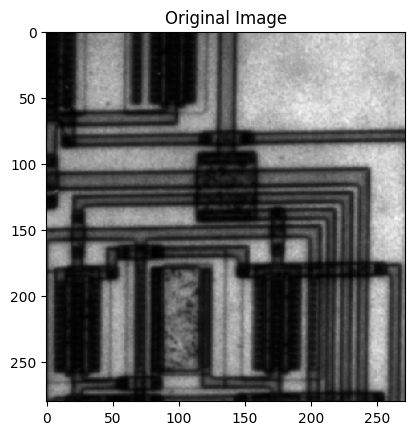

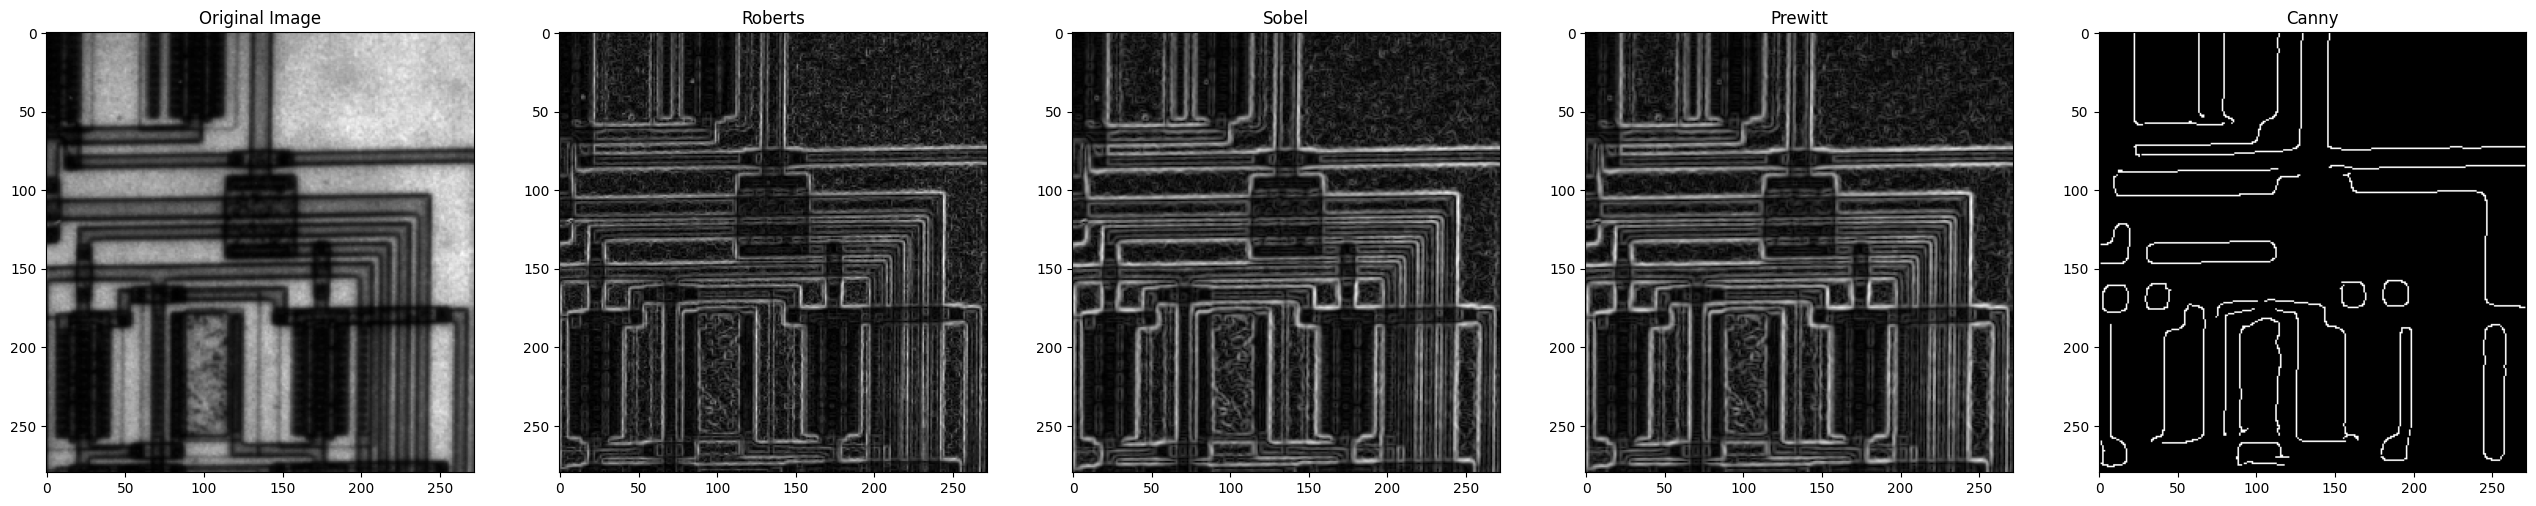

In [26]:
# 1. Built-in Sobel, Prewill, Roberts, Canny

img = io.imread('circuit.tif')
show_images([img], ['Original Image'])

edges_roberts = roberts(img)
edges_sobel = sobel(img)
edges_prewitt = prewitt(img)
edges_canny = canny(img, sigma=3)

show_images([img, edges_roberts, edges_sobel, edges_prewitt, edges_canny], 
            ['Original Image', 'Roberts', 'Sobel', 'Prewitt', 'Canny'])



In [39]:
# 2. Custom Sobel (V-H-Both)

def custom_sobel(img):
    Kx = np.array([[ -1, 0, 1],
                   [ -2, 0, 2],
                   [ -1, 0, 1]])
    Ky = np.array([[ 1, 2, 1],
                   [ 0, 0, 0],
                   [ -1, -2, -1]])
    
    # Ix = convolve2d(img, Kx)
    # Iy = convolve2d(img, Ky)
    Ix = np.zeros(img.shape)
    Iy = np.zeros(img.shape)

    for rowidx, row in enumerate(img):
        for colidx, col in enumerate(row):
            if rowidx == 0 or rowidx == img.shape[0]-1 or colidx == 0 or colidx == img.shape[1]-1:
                continue
            else:
                Ix[rowidx, colidx] = (Kx * img[rowidx-1:rowidx+2, colidx-1:colidx+2]).sum()
                Iy[rowidx, colidx] = (Ky * img[rowidx-1:rowidx+2, colidx-1:colidx+2]).sum()
    
    G = np.hypot(Ix, Iy)
    G = (G / G.max()) * 255
    theta = np.arctan2(Iy, Ix)
    
    return (G, Ix, Iy)





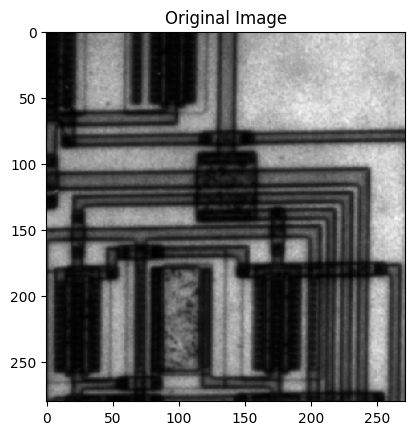

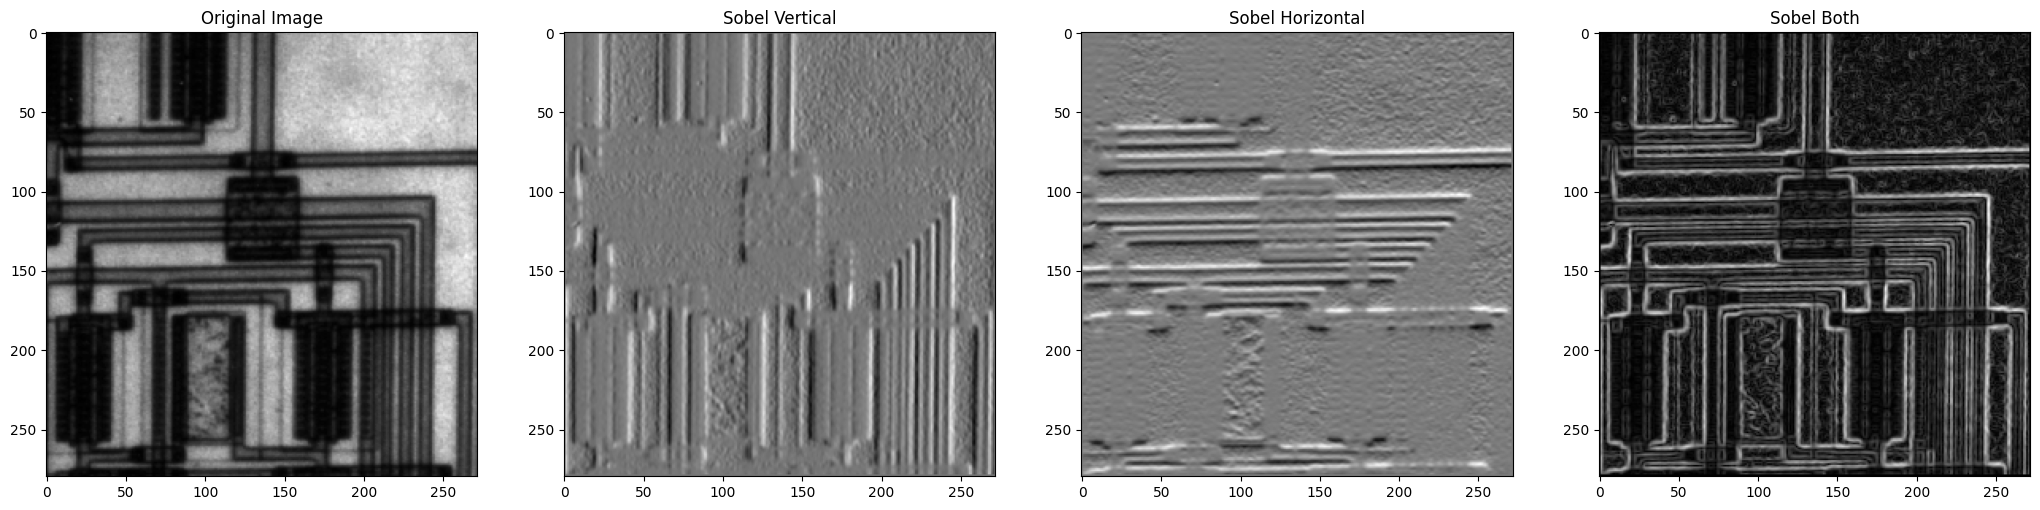

In [40]:
img = io.imread('circuit.tif')
show_images([img], ['Original Image'])

G, Ix, Iy = custom_sobel(img)
show_images([img, Ix, Iy, G], ['Original Image', 'Sobel Vertical', 'Sobel Horizontal', 'Sobel Both'])

In [29]:
# 3. Custom LoG
thres= 30
def custom_log(img, thres):
    if img.ndim == 3:  # RGB image
        img_gray = color.rgb2gray(img)
    else:
        img_gray = img


    smoothed = gaussian(img_gray, sigma=1)

    # Step 2: Define two Laplacian of Gaussian (LoG) filters
    f1 = np.array([
        [-1, -1, -1],
        [-1,  8, -1],
        [-1, -1, -1]
    ], dtype=float)

    f2 = np.array([
        [ 0,  1,  0],
        [ 1, -4,  1],
        [ 0,  1,  0]
    ], dtype=float)

    
    # F1_img = convolve2d(smoothed, f1, mode='same', boundary='symm')
    # F2_img = convolve2d(smoothed, f2, mode='same', boundary='symm')

    F1_img = np.zeros(smoothed.shape)
    F2_img = np.zeros(smoothed.shape)

    for rowidx, row in enumerate(smoothed):
        for colidx, col in enumerate(row):
            if rowidx == 0 or rowidx == smoothed.shape[0]-1 or colidx == 0 or colidx == smoothed.shape[1]-1:
                continue
            else:
                F1_img[rowidx, colidx] = (f1 * smoothed[rowidx-1:rowidx+2, colidx-1:colidx+2]).sum()
                F2_img[rowidx, colidx] = (f2 * smoothed[rowidx-1:rowidx+2, colidx-1:colidx+2]).sum()

    
    threshold1 = (thres / 100) * np.max(F1_img)
    threshold2 = (thres / 100) * np.max(F2_img)

    edges_F1 = np.where(np.abs(F1_img) > threshold1, 1.0, 0.0)
    edges_F2 = np.where(np.abs(F2_img) > threshold2, 1.0, 0.0)

    return (smoothed, F1_img, edges_F1, F2_img, edges_F2)




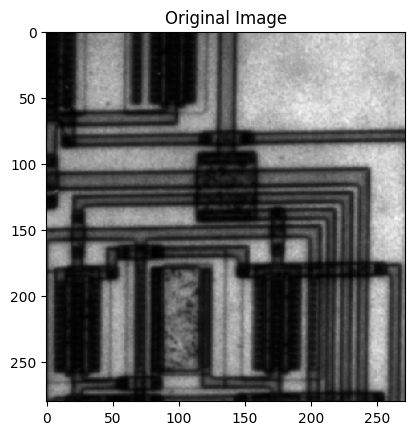

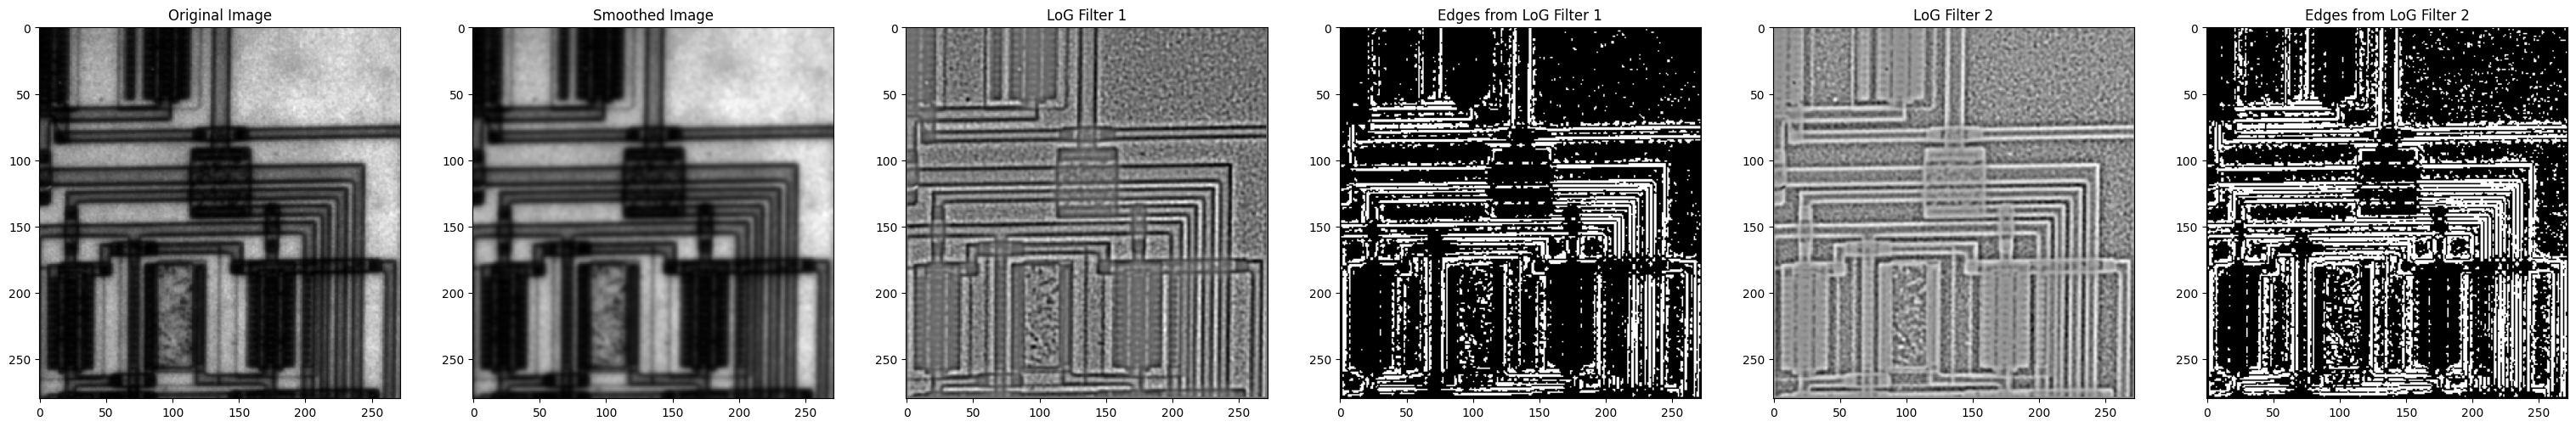

In [30]:
img = io.imread('circuit.tif')
show_images([img], ['Original Image'])
smothed, F1_img, edges_F1, F2_img, edges_F2 = custom_log(img, thres)
show_images([img, smothed, F1_img, edges_F1, F2_img, edges_F2], 
            ['Original Image', 'Smoothed Image', 'LoG Filter 1', 
            'Edges from LoG Filter 1', 'LoG Filter 2', 'Edges from LoG Filter 2'])

In [31]:
'''
Optional
1-Make edge detection
2-Multiply by factor < 1
3-Subtract (Orginal Image) - (Edge Detection Image)
'''

'\nOptional\n1-Make edge detection\n2-Multiply by factor < 1\n3-Subtract (Orginal Image) - (Edge Detection Image)\n'

In [50]:
def edge_subtraction_enhancement(img, factor=0.5):
    

    if img.ndim == 3:
        img_gray = color.rgb2gray(img)
    else:
        img_gray = img

    edge_img, IX, IY = custom_sobel(img_gray)

    scaled_edges = edge_img * factor

    enhanced = img_gray - scaled_edges
    return img_gray, edge_img, enhanced

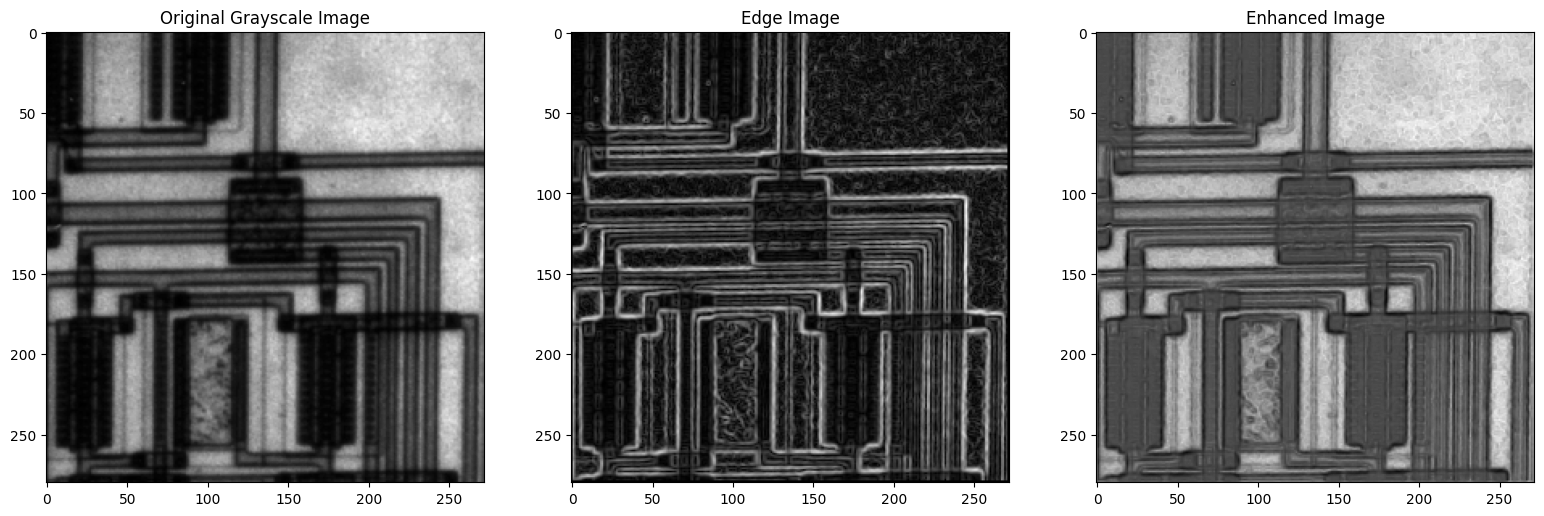

In [54]:
img = io.imread('circuit.tif')
img_gray, edge_img, enhanced = edge_subtraction_enhancement(img, 0.5)

show_images([img_gray, edge_img, enhanced],
            ['Original Grayscale Image', 'Edge Image', 'Enhanced Image'])